Run the installation cell once, then choose **Run all**. All data is synthetic. The saved outputs were executed against the local package.

[Documentation](https://datakim.github.io/lendrisk/)


In [ ]:
%pip install -q "git+https://github.com/datakim/lendrisk.git@v0.1.0a2" matplotlib

# Turn numerical credit variables into explainable scores

This guide starts with one variable, then builds and evaluates a complete
scorecard. All data is synthetic. The first example gives a debt ratio a
deliberately increasing event probability so the binning behavior is easy to see.

## 1. Learn readable bins


In [1]:
import numpy as np

from lendrisk import OptimalBinning

rng = np.random.default_rng(42)
debt_ratio = rng.uniform(0.05, 0.95, 1_000)
default = rng.binomial(1, 0.02 + 0.42 * debt_ratio**2)
bins = OptimalBinning(max_n_bins=5, monotonic_trend="ascending").fit(debt_ratio, default)
print(bins.status_)
print(bins.table()[["bin", "count", "event_rate", "woe"]].round(3))

OPTIMAL
                     bin  count  event_rate    woe
0      [-inf, 0.0938228)     50       0.020  1.887
1  [0.0938228, 0.407591)    350       0.060  1.120
2   [0.407591, 0.587315)    200       0.140  0.191
3   [0.587315, 0.815282)    250       0.216 -0.327
4        [0.815282, inf)    150       0.407 -1.234
5                Missing      0       0.165  0.000
6                Special      0       0.165  0.000


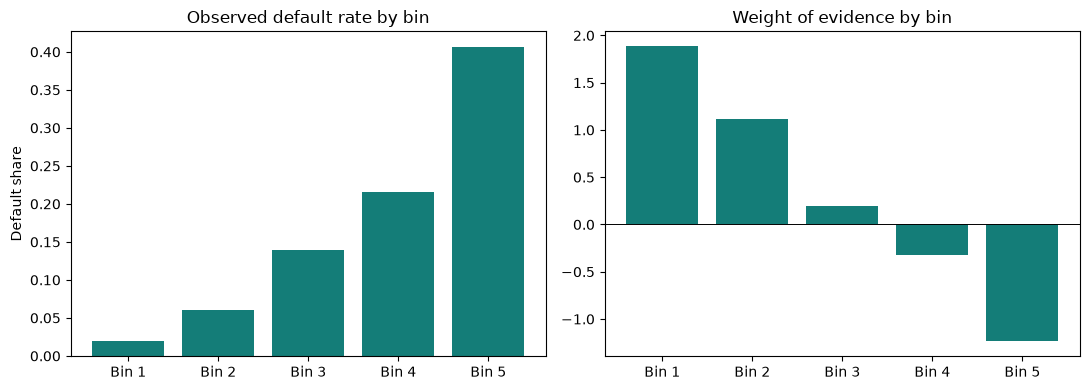

In [2]:
import matplotlib.pyplot as plt

regular = bins.table().query("bin != 'Missing' and bin != 'Special'")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = [f"Bin {i + 1}" for i in range(len(regular))]
axes[0].bar(labels, regular["event_rate"], color="#147d78")
axes[0].set_title("Observed default rate by bin")
axes[0].set_ylabel("Default share")
axes[1].bar(labels, regular["woe"], color="#147d78")
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set_title("Weight of evidence by bin")
fig.tight_layout()
plt.show()

- `max_n_bins=5` allows up to five regular bins; it does not force five.
- `monotonic_trend="ascending"` requires each next bin's default rate to be at least the previous rate.
- `event_rate` is the observed fraction of labels equal to 1 within each bin.
- **WoE** compares the bin's share of all non-defaults with its share of all defaults.
  Positive values indicate relative concentration of non-defaults; negative values indicate defaults.

`OPTIMAL` means the solver proved optimality in its candidate prebin search
space, at the documented objective precision. It does not mean the feature
or future model is perfect. A time-limited feasible solution is labeled
`FEASIBLE`; no feasible solution raises `BinningOptimizationError`.

Transform new numerical values with the learned boundaries:


In [3]:
new_values = [0.10, 0.50, 0.90, np.nan]
print(bins.transform(new_values, metric="indices"))
print(bins.transform(new_values, metric="woe"))

[1 2 4 5]
[ 1.12008551  0.19105524 -1.23423646  0.        ]


Missing and configured special values have their own report buckets. If a
reserved bucket had no training observations, its WoE is neutral (zero).

## 2. Split the data before fitting a scorecard

This separate classification dataset contains four artificial numerical features.
The labels are about evenly balanced and have no specified real-world horizon;
they demonstrate the workflow rather than calibrated credit probabilities.


In [4]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from lendrisk import LogisticScorecard, credit_metrics

X, y = make_classification(n_samples=600, n_features=4, n_redundant=0, random_state=42)
X = pd.DataFrame(X, columns=["x0", "x1", "x2", "x3"])
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
model = LogisticScorecard(pdo=20, base_score=600, base_odds=50).fit(X_train, y_train)
pd_hat = model.predict_proba(X_test)[:, 1]
points = model.score_points(X_test)
print(credit_metrics(y_test, pd_hat))
print(pd.DataFrame({"model_pd": pd_hat, "score_points": points}).head().round(3))

{'n_observations': 150.0, 'event_rate': 0.5, 'mean_predicted_pd': 0.5306818677073242, 'roc_auc': 0.9728, 'gini': 0.9456, 'ks': 0.8933333333333333, 'brier_score': 0.056929618522820795, 'log_loss': 0.19585679450530247}
   model_pd  score_points
0     0.986       364.105
1     0.098       551.107
2     0.978       377.398
3     0.842       438.830
4     0.575       478.428


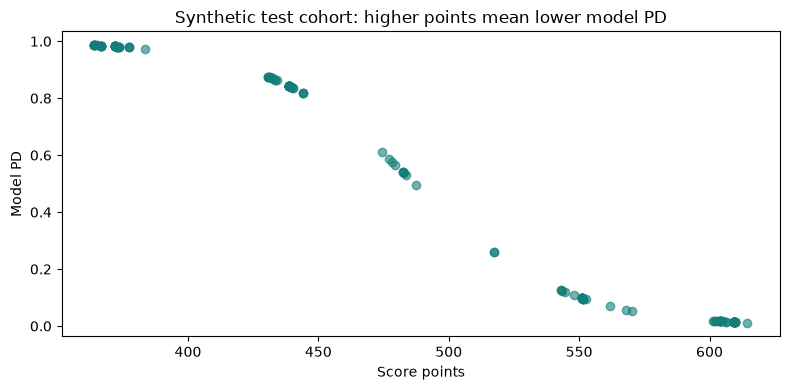

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(points, pd_hat, color="#147d78", alpha=0.6)
ax.set_xlabel("Score points")
ax.set_ylabel("Model PD")
ax.set_title("Synthetic test cohort: higher points mean lower model PD")
fig.tight_layout()
plt.show()

The scorecard learns bins **inside `fit` on the training cohort**, transforms
those variables into WoE, and fits logistic regression. Evaluation applies the
learned transformation to the test cohort. Do not bin the entire dataset before
splitting. For a production credit problem, prefer a time-based validation cohort
that reflects the underwriting date and the outcome horizon.

Read the diagnostics by question:

| Diagnostic | Question answered |
| --- | --- |
| ROC AUC / Gini / KS | Does the score separate events from non-events? |
| Brier score / log loss | How close are predicted probabilities to observed labels? |
| Event rate vs. mean predicted PD | Is average predicted risk aligned with this cohort's observed event share? |

No single diagnostic establishes calibration or suitability. The API provides
calculated values; choose acceptance criteria for your population and task.

## 3. Understand the score scale


At `base_score=600`, `base_odds=50` means 50 non-defaults per default: a model PD
of 1/51, about 1.96%. `pdo=20` means 20 extra points double those good:bad odds.
At 620 points the odds are 100:1 and model PD is about 0.99%.

This is a mathematical mapping of model probabilities. A conventional point
range or attractive score scale does not establish that predictions are calibrated.

## 4. Inspect the point contributions


In [6]:
contributions = model.table()[["variable", "bin", "count", "woe", "points"]]
print(contributions.head(10).round(3))
print("Add this intercept once:", round(model.intercept_points, 3))

  variable                    bin  count    woe   points
0       x0       [-inf, -1.25061)     45 -0.307    4.407
1       x0   [-1.25061, -0.84221)     45 -0.043    0.625
2       x0  [-0.84221, -0.180165)    113  0.018   -0.252
3       x0  [-0.180165, 0.890319)    179  0.056   -0.798
4       x0        [0.890319, inf)     68  0.058   -0.833
5       x0                Missing      0  0.000   -0.000
6       x0                Special      0  0.000   -0.000
7       x1       [-inf, -1.00367)    113  3.798  118.557
8       x1  [-1.00367, -0.394995)     90  1.933   60.357
9       x1  [-0.394995, 0.118832)     44 -0.268   -8.375
Add this intercept once: 488.142


Each applicant selects one bin per input variable. The score is the sum of
those bin contributions plus the intercept once. The table gives the exact
unrounded calculation used by the model. It explains point construction;
adverse-action reason codes are outside the current alpha scope.

## 5. Bring a defined credit target

For your own data, use numerical feature columns and a binary target:
**1 means the event you define; 0 means non-event**. State the event horizon,
ensure labels have matured, and exclude information unavailable at application
time. Preserve the same feature names and column order at prediction time.

[Input recipe](https://github.com/datakim/lendrisk/blob/main/docs/your-data.md#credit-feature-data) · [Glossary](https://github.com/datakim/lendrisk/blob/main/docs/glossary.md) ·
[Upstream scope and differences](https://github.com/datakim/lendrisk/blob/main/docs/upstream.md) ·
[Open the scorecard notebook](https://colab.research.google.com/github/datakim/lendrisk/blob/main/notebooks/02_native_scorecard.ipynb)
